# Dimensionality Reduction using PCA on the Iris Dataset

## 1. Import libraries 

In [8]:
import pandas as pd
from sklearn import datasets

## 2. Load and Preprocess Data

In [9]:
# Load the Iris dataset
iris = datasets.load_iris()

# Convert to Pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Add target column
df['target_name'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})  # Map target to names

In [10]:
df.shape

(150, 6)

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   target_name        150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB


In [13]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'target_name'],
      dtype='object')

In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 3. Apply Principal Component Analysis

In [15]:
from sklearn.decomposition import PCA

# Selecting only feature columns (dropping target)
X = df.iloc[:, :-2]  # Select all columns except the last two (target and target_name)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Convert back to DataFrame for easier visualization
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = df['target']
df_pca['target_name'] = df['target_name']

print(df_pca.head())  # Display the first few rows

        PC1       PC2  target target_name
0 -2.684126  0.319397       0      setosa
1 -2.714142 -0.177001       0      setosa
2 -2.888991 -0.144949       0      setosa
3 -2.745343 -0.318299       0      setosa
4 -2.728717  0.326755       0      setosa


## 4.  Visualize the Reduced Data

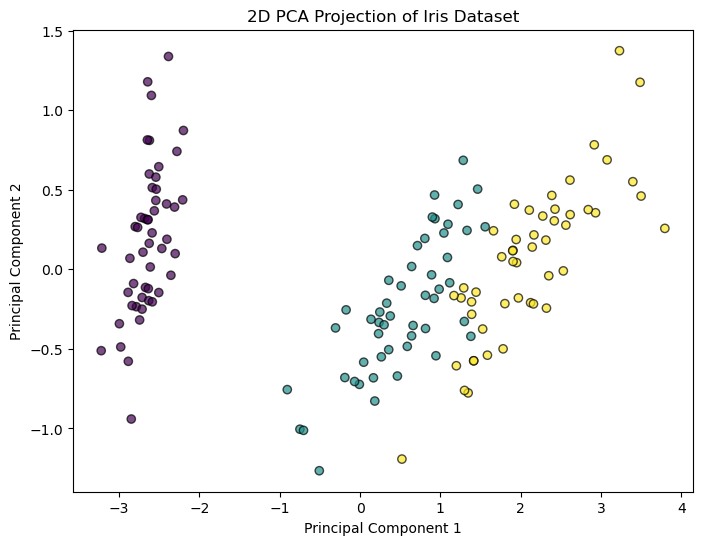

In [17]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['target'], cmap='viridis', edgecolor='k', alpha=0.7)

# Add labels and title
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Iris Dataset")

# Add legend
plt.show()

# Conclusion on Dimensionality Reduction using PCA on the Iris Dataset

1. Project Summary
This project focused on dimensionality reduction using Principal Component Analysis (PCA) to transform a high-dimensional dataset into a 2D representation for visualization. The Iris dataset was chosen due to its well-defined structure, containing four numerical features and three species classes.

By applying PCA, we reduced the dataset to two principal components, allowing us to visualize the relationships between different species in a scatter plot.

2. Methods Used and Their Effectiveness

2.1 Data Preprocessing and Loading
The Iris dataset was loaded using pandas DataFrame, making it easier to manage and explore.

Features (sepal length, sepal width, petal length, petal width) were extracted, and species labels were mapped for better interpretation.

✅ Effectiveness: Using pandas made data handling more structured and allowed easy integration with visualization libraries.

2.2 Applying PCA for Dimensionality Reduction
PCA was applied to reduce the four-dimensional feature space into two principal components (PC1 and PC2).

PCA transformed the dataset while retaining maximum variance, ensuring minimal information loss.

✅ Effectiveness: PCA successfully reduced dimensions while preserving most of the dataset’s variance, making it useful for visualization.

2.3 Data Visualization with Scatter Plot
The reduced data was visualized using matplotlib, with colors representing different species.

The plot provided insights into the distribution and overlap of species in 2D space.

✅ Effectiveness: The scatter plot clearly showed Setosa as a distinct cluster, while Versicolor and Virginica overlapped, revealing PCA’s limitations in complete class separability.

3. Key Observations and Findings
🔹 PCA efficiently reduced dimensionality, making high-dimensional data more interpretable.
🔹 Setosa was clearly distinguishable, but Versicolor and Virginica overlapped, indicating PCA’s limitation in class separability.
🔹 Some variance was lost, but PCA retained most of the dataset’s information in two dimensions.
🔹 Linear assumption of PCA means it may not be the best choice for datasets with non-linear relationships.

4. Limitations of PCA in This Project
⚠️ Loss of Information – Reducing dimensions inevitably loses some details.
⚠️ Class Overlap – PCA does not optimize for class separability, leading to some overlap between similar classes.
⚠️ Linear Assumption – PCA only captures linear correlations, making it less effective for datasets with complex, non-linear patterns.

5. Alternative Approaches for Improvement
🔸 Linear Discriminant Analysis (LDA) – Better for classification since it maximizes class separation.
🔸 t-SNE / UMAP – More effective for non-linear relationships and high-dimensional clustering.
🔸 Feature Engineering – Selecting or engineering better features could improve class distinction before applying PCA.

6. Final Thoughts
This project demonstrated how PCA can be used for dimensionality reduction, making high-dimensional data easier to visualize and analyze. While PCA is powerful for feature reduction, it has limitations in class separability. Future enhancements like LDA, t-SNE, or UMAP could provide better visualization and classification accuracy.